In [ ]:
# Initialization
import ee, geemap, os, itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

try: ee.Initialize(project='geeexercise')
except: ee.Authenticate(); ee.Initialize(project='geeexercise')
print('GEE OK')

In [ ]:
# Configurations
aoi  = ee.FeatureCollection('projects/geeexercise/assets/gebe-island-aoi-land').geometry()
yrs  = list(range(2019, 2026))
crs, scale = 'EPSG:32752', 10

# Sub-period split at 2022 for baseline change
early_yrs = [2019, 2020, 2021, 2022]
late_yrs  = [2022, 2023, 2024, 2025]

# Load assets
stack_tmpl = 'projects/geeexercise/assets/new-thesis-img/FeatureStack_{yr}'
lulc_tmpl  = 'projects/geeexercise/assets/new-thesis-img/LULC_Gebe_{yr}_RF200trees'

# LULC schema
codes  = [1,2,3,4,5]
lbls   = ['Vegetation','BareSoil','Bush','BuiltUp','Waterbodies']
pal    = ['#1a9641','#d2b48c','#a6d96a','#d7191c','#2b83ba']
c2n    = dict(zip(codes, lbls))

# Load bands (IronOxide excluded)
all_12      = ['NDVI','EVI','MSAVI2','BSI','NDWI','NBR','Clay','Ferrous','IronOxide','VV','VH','VV_VH_ratio']
feat_bands  = ['NDVI','EVI','MSAVI2','BSI','NDWI','NBR','Clay','Ferrous','VV','VH','VV_VH_ratio']
trend_bands = ['NDVI','BSI','VV','VH','VV_VH_ratio']

# Transition codes counted as disturbance (veg > bare, veg > builtup, bare > bare, bare > builtup)
hotspot_codes = [12, 14, 22, 24]

# Export destination
rast_dir = 'gee-exports-new/phase-4-new'
csv_dir  = '/content/drive/MyDrive/gee-exports-new/phase-4-new/csv'
os.makedirs(csv_dir, exist_ok=True)

In [ ]:
aoi_ha = aoi.area(maxError=1).getInfo() / 1e4
print(f'AOI: {aoi_ha:,.2f} ha')

def pull_stack(yr):
    return (ee.Image(stack_tmpl.format(yr=yr))
              .rename(all_12).select(feat_bands).clip(aoi))

def pull_lulc(yr):
    return ee.Image(lulc_tmpl.format(yr=yr)).rename('lulc').clip(aoi)

stacks = {yr: pull_stack(yr) for yr in yrs}
lulcs  = {yr: pull_lulc(yr)  for yr in yrs}

# Band check (one year for checking)
ok = stacks[2022].bandNames().getInfo() == feat_bands
print(f'Stacks loaded, band names {"OK" if ok else "MISMATCH"}')
print(f'LULC loaded for {list(lulcs.keys())}')

In [ ]:
# Per-class area per year, one reduceRegion call per class per year
px = ee.Image.pixelArea().divide(1e4)

def class_areas(img):
    return {c: px.updateMask(img.eq(c))
                .reduceRegion(ee.Reducer.sum(), aoi, scale, maxPixels=1e10, bestEffort=True)
                .get('area').getInfo()
            for c in codes}

print('Computing ...')
rows = []
for yr in yrs:
    s   = class_areas(lulcs[yr])
    row = {'Year': yr}
    for c, nm in zip(codes, lbls):
        ha = s.get(c, 0)
        row[f'{nm}_ha']  = round(ha, 2)
        row[f'{nm}_pct'] = round(ha / aoi_ha * 100, 3)
    row['Total_ha'] = round(sum(s.values()), 2)
    rows.append(row)
    print(f'  {yr}: ' + '  '.join(f'{nm}={s.get(c,0):.0f}' for c,nm in zip(codes,lbls)))

area_df = pd.DataFrame(rows).set_index('Year')
print()
print(area_df[[f'{n}_ha' for n in lbls] + ['Total_ha']].to_string())

In [ ]:
def t_img(ly_from, ly_to):
    # Encode as from*10 + to. Exapmle: 12 = veg->bare
    return ly_from.multiply(10).add(ly_to).rename('transition').toInt16()

def t_matrix(ly_from, ly_to):
    ti = t_img(ly_from, ly_to)
    grouped = (px.addBands(ti)
                 .reduceRegion(ee.Reducer.sum().group(groupField=1, groupName='code'),
                               aoi, scale, maxPixels=1e10, bestEffort=True)
                 .get('groups').getInfo())
    mat = pd.DataFrame(0.0, index=lbls, columns=lbls)
    for entry in grouped:
        fc, tc = int(entry['code']) // 10, int(entry['code']) % 10
        if fc in c2n and tc in c2n:
            mat.loc[c2n[fc], c2n[tc]] = round(entry['sum'], 2)
    return mat

# Consecutive pairs + key intervals
consec  = [(yrs[i], yrs[i+1]) for i in range(len(yrs)-1)]
key_ivl = [(2019,2022),(2022,2025),(2019,2025)]
all_ivl = consec + key_ivl

t_imgs = {(a,b): t_img(lulcs[a], lulcs[b]) for a,b in all_ivl}

print('Computing ...')
t_mats = {}
for a,b in all_ivl:
    t_mats[(a,b)] = t_matrix(lulcs[a], lulcs[b])
    print(f'  {a}-{b} done')

print('\n2019 -> 2025:')
print(t_mats[(2019,2025)].to_string())

In [ ]:
# Creating time-indexed ImageCollections for OLS, TS, MK
def ts_col(band, yr_list):
    return ee.ImageCollection([
        stacks[yr].select(band)
                  .addBands(ee.Image.constant(i).rename('time').toFloat())
                  .set('year', yr)
        for i, yr in enumerate(yr_list)
    ])

full_col  = {b: ts_col(b, yrs)       for b in trend_bands}
early_col = {b: ts_col(b, early_yrs) for b in trend_bands}
late_col  = {b: ts_col(b, late_yrs)  for b in trend_bands}

# OLS via linearFit
ols_full  = {b: full_col[b].select(['time', b]).reduce(ee.Reducer.linearFit()).select('scale').rename(f'{b}_ols') for b in trend_bands}
ols_early = {b: early_col[b].select(['time', b]).reduce(ee.Reducer.linearFit()).select('scale').rename(f'{b}_ols') for b in trend_bands}
ols_late  = {b: late_col[b].select(['time', b]).reduce(ee.Reducer.linearFit()).select('scale').rename(f'{b}_ols') for b in trend_bands}

# Theil-Sen
def theilsen(col, band, n):
    imgs = [ee.Image(col.toList(n).get(i)).select(band) for i in range(n)]
    slopes = [imgs[j].subtract(imgs[i]).divide(j-i) for i,j in itertools.combinations(range(n),2)]
    return ee.ImageCollection(slopes).median().rename(f'{band}_ts')

ts_full  = {b: theilsen(full_col[b],  b, len(yrs))       for b in trend_bands}
ts_early = {b: theilsen(early_col[b], b, len(early_yrs)) for b in trend_bands}
ts_late  = {b: theilsen(late_col[b],  b, len(late_yrs))  for b in trend_bands}

# Mann-Kendall, manual pixel-wise implementation
def mannkendall_gee(img_list, band):
    """
    Mann-Kendall S-statistic dan p-value per piksel.
    N=7: 21 pasangan, Var(S) = 7*6*19/18 = 44.333.
    P-value: two-tailed normal approximation.
    """
    n = len(img_list)
    signs = []
    for i, j in itertools.combinations(range(n), 2):
        diff = img_list[j].subtract(img_list[i])
        signs.append(diff.gt(0).subtract(diff.lt(0)).toFloat())

    S = ee.ImageCollection(signs).sum().rename(f'{band}_S')

    var_S    = ee.Number(n * (n - 1) * (2 * n + 5) / 18)
    sqrt_var = var_S.sqrt()

    # Z with continuity correction
    Z = (S.subtract(S.gt(0).toFloat())
          .add(S.lt(0).toFloat())
          .divide(sqrt_var)
          .rename(f'{band}_Z'))

    # Two-tailed p-value via normal CDF approximation
    absZ  = Z.abs()
    t     = ee.Image(1.0).divide(ee.Image(1.0).add(absZ.multiply(0.2316419)))
    poly  = (t.multiply(0.319381530)
              .add(t.pow(2).multiply(-0.356563782))
              .add(t.pow(3).multiply(1.781477937))
              .add(t.pow(4).multiply(-1.821255978))
              .add(t.pow(5).multiply(1.330274429)))
    phi_c = poly.multiply(absZ.pow(2).multiply(-0.5).exp().multiply(0.3989422804))
    pval  = phi_c.multiply(2).clamp(0, 1).rename(f'{band}_mk_pval')
    sig   = pval.lte(0.05).rename(f'{band}_mk_sig')

    return {'S': S, 'Z': Z, 'pval': pval, 'sig': sig}

img_lists = {b: [stacks[yr].select(b) for yr in yrs] for b in trend_bands}

print('Computing Mann-Kendall (manual pixel-wise)...')
mk = {}
for b in trend_bands:
    mk[b] = mannkendall_gee(img_lists[b], b)
    print(f'  {b}: defined')

# Acceleration = late_slope - early_slope
accel = {b: ts_late[b].subtract(ts_early[b]).rename(f'{b}_accel') for b in trend_bands}

# TS slope masked to MK-significant pixels only
sig_slopes = {b: ts_full[b].updateMask(mk[b]['sig']).rename(f'{b}_ts_sig') for b in trend_bands}

print('OLS, Theil-Sen, MK (manual), acceleration all defined.')

In [ ]:
# Hotspot: NDVI declining + BSI increasing (both MK-sig) + disturbance transition
ndvi_decline = ts_full['NDVI'].lt(0).And(mk['NDVI']['sig'])
bsi_increase = ts_full['BSI'].gt(0).And(mk['BSI']['sig'])

dist_mask = ee.Image(0).byte()
for c in hotspot_codes:
    dist_mask = dist_mask.Or(t_imgs[(2019,2025)].eq(c))

hotspot = (ndvi_decline.And(bsi_increase).And(dist_mask)
                       .rename('degradation_hotspot').toByte().clip(aoi))
print(f'Hotspot layer defined. Codes: {hotspot_codes}')

In [ ]:
def aoi_mean(img, band, sc=100):
    v = (img.select(band)
           .reduceRegion(ee.Reducer.mean(), aoi, sc, maxPixels=1e9, bestEffort=True)
           .get(band).getInfo())
    return float(v) if v is not None else float('nan')

print('Pulling per-year index means...')
idx_means = {b: [aoi_mean(stacks[yr], b) for yr in yrs] for b in trend_bands}
for b in trend_bands:
    print(f'  {b}: ' + '  '.join(f'{v:.4f}' for v in idx_means[b]))

print('\nSlope means...')
ols_mean   = {b: float(ols_full[b].reduceRegion(ee.Reducer.mean(), aoi, 100, maxPixels=1e9, bestEffort=True).get(f'{b}_ols').getInfo() or 'nan') for b in trend_bands}
ts_mean    = {b: float(ts_full[b].reduceRegion(ee.Reducer.mean(), aoi, 100, maxPixels=1e9, bestEffort=True).get(f'{b}_ts').getInfo() or 'nan')  for b in trend_bands}
mk_frac    = {}
accel_mean = {}

for b in trend_bands:
    raw = mk[b]['sig'].reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi,
        scale=100,
        maxPixels=1e9,
        bestEffort=True
    ).getInfo()
    v = raw.get(f'{b}_mk_sig')
    mk_frac[b] = float(v) * 100 if v is not None else float('nan')

    v2 = accel[b].reduceRegion(ee.Reducer.mean(), aoi, 100, maxPixels=1e9, bestEffort=True).get(f'{b}_accel').getInfo()
    accel_mean[b] = float(v2) if v2 is not None else float('nan')

    print(f'  {b}: OLS={ols_mean[b]:.5f}  TS={ts_mean[b]:.5f}  MK_sig={mk_frac[b]:.1f}%  accel={accel_mean[b]:.6f}')

In [ ]:
# Chart 1 (LULC stacked bar)
fig, ax = plt.subplots(figsize=(11,5))
bottoms = np.zeros(len(yrs))
for nm, clr in zip(lbls, pal):
    vals = area_df[f'{nm}_ha'].values.astype(float)
    ax.bar(yrs, vals, 0.65, bottom=bottoms, label=nm, color=clr, edgecolor='white', lw=0.4)
    bottoms += vals
ax.set(xlabel='Year', ylabel='Area (ha)', title='Annual LULC Area of Gebe Island 2019-2025')
ax.set_xticks(yrs); ax.legend(fontsize=9); ax.grid(axis='y', ls='--', alpha=0.35)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig(f'{csv_dir}/chart1_lulc_stacked.png', dpi=150, bbox_inches='tight'); plt.show()

In [ ]:
# Chart 2 (% of AOI line)
fig, ax = plt.subplots(figsize=(11,5))
for nm, clr, mk_ in zip(lbls, pal, ['o','s','^','D','v']):
    ax.plot(yrs, area_df[f'{nm}_pct'].values, marker=mk_, color=clr, lw=2, ms=7, label=nm)
ax.set(xlabel='Year', ylabel='% of AOI', title='LULC Coverage as % of AOI 2019-2025')
ax.set_xticks(yrs); ax.legend(fontsize=9); ax.grid(ls='--', alpha=0.35)
plt.tight_layout()
plt.savefig(f'{csv_dir}/chart2_lulc_pct.png', dpi=150, bbox_inches='tight'); plt.show()

In [ ]:
veg_ha    = area_df['Vegetation_ha'].values.astype(float)
veg_loss  = veg_ha[0] - veg_ha
mine_ha   = (area_df['BareSoil_ha'] + area_df['BuiltUp_ha']).values.astype(float)
mine_exp  = mine_ha - mine_ha[0]

def dual_chart(abs_vals, cum_vals, abs_clr, cum_clr, abs_label, cum_label, title, fname):
    fig, (a1, a2) = plt.subplots(1,2,figsize=(13,5))
    bars = a1.bar(yrs, abs_vals, color=abs_clr, edgecolor='white', lw=0.4, width=0.65)
    a1.set(xlabel='Year', ylabel=abs_label)
    a1.set_xticks(yrs); a1.grid(axis='y', ls='--', alpha=0.35)
    a1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
    for bar, v in zip(bars, abs_vals):
        a1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3, f'{v:,.0f}', ha='center', fontsize=8)

    a2.plot(yrs, cum_vals, 'o-', color=cum_clr, lw=2.5, ms=8)
    a2.fill_between(yrs, cum_vals, alpha=0.15, color=cum_clr)
    a2.axhline(0, color='grey', ls='--', lw=0.8)
    a2.set(xlabel='Year', ylabel=cum_label)
    a2.set_xticks(yrs); a2.grid(ls='--', alpha=0.35)
    a2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

    plt.suptitle(title, fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'{csv_dir}/{fname}', dpi=150, bbox_inches='tight'); plt.show()

# Chart 3 (vegetation loss)
dual_chart(veg_ha, veg_loss, '#1a9641', '#8b0000',
           'Vegetation Area (ha)', 'Cumulative Loss (ha)',
           'Vegetation Loss of Gebe Island 2019-2025', 'chart3_veg_loss.png')

# Chart 4 (mining footprint)
dual_chart(mine_ha, mine_exp, '#b85c1a', '#b85c1a',
           'Mining Footprint (ha)', 'Cumulative Expansion (ha)',
           'Mining Footprint Expansion of Gebe Island 2019-2025', 'chart4_mining.png')

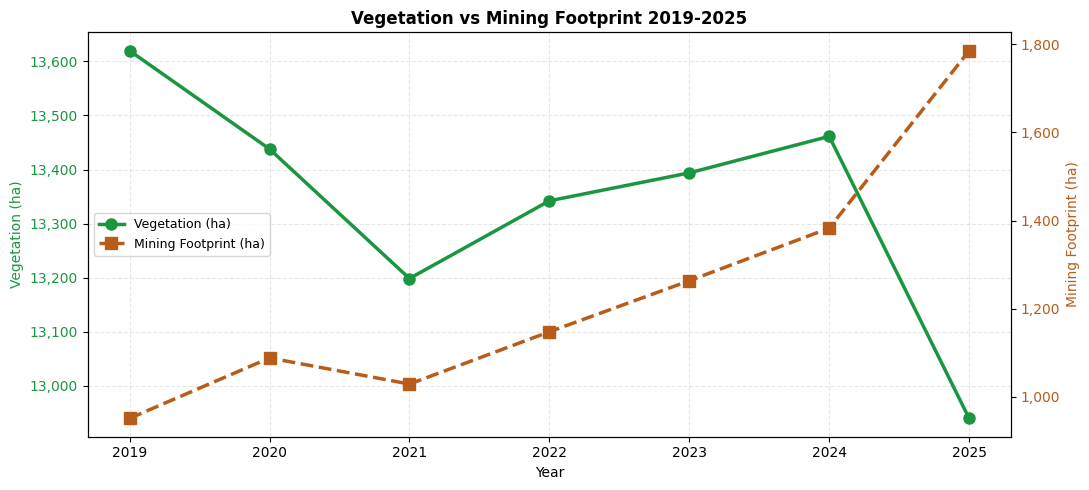

In [ ]:
# Chart 5 (combined dual-axis)
fig, ax_l = plt.subplots(figsize=(11,5))
ax_r = ax_l.twinx()
l1, = ax_l.plot(yrs, veg_ha,  'o-',  color='#1a9641', lw=2.5, ms=8, label='Vegetation (ha)')
l2, = ax_r.plot(yrs, mine_ha, 's--', color='#b85c1a', lw=2.5, ms=8, label='Mining Footprint (ha)')
ax_l.set_ylabel('Vegetation (ha)', color='#1a9641'); ax_l.tick_params(axis='y', labelcolor='#1a9641')
ax_r.set_ylabel('Mining Footprint (ha)', color='#b85c1a'); ax_r.tick_params(axis='y', labelcolor='#b85c1a')
for ax_ in [ax_l, ax_r]:
    ax_.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax_l.set_xlabel('Year'); ax_l.set_xticks(yrs); ax_l.grid(ls='--', alpha=0.3)
ax_l.set_title('Vegetation vs Mining Footprint 2019-2025', fontweight='bold')
ax_l.legend([l1,l2], [l1.get_label(), l2.get_label()], loc='center left', fontsize=9)
plt.tight_layout()
plt.savefig(f'{csv_dir}/chart5_dualaxis.png', dpi=150, bbox_inches='tight'); plt.show()

In [ ]:
# Chart 6 (transition heatmaps 2x3)
short = ['Veg','Bare','Bush','Built','Water']
fig, axes = plt.subplots(2,3,figsize=(18,9))
for ax_, (a,b) in zip(axes.flat, consec):
    tm = t_mats[(a,b)].copy(); tm.index = tm.columns = short
    sns.heatmap(tm, ax=ax_, annot=True, fmt='.0f', cmap='OrRd',
                linewidths=0.4, linecolor='white', cbar_kws={'label':'Area (ha)','shrink':0.75},
                annot_kws={'size':8})
    ax_.set_title(f'{a}-{b}'); ax_.set(xlabel='To', ylabel='From')
plt.suptitle('LULC Transition Matrices - Consecutive Pairs (ha)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{csv_dir}/chart6_transitions.png', dpi=150, bbox_inches='tight'); plt.show()

In [ ]:
# Chart 7 (NDVI & BSI trajectory with OLS + TS overlay)
fig, axes = plt.subplots(1,2,figsize=(13,5))
n = len(yrs)
for ax_, band, clr in zip(axes, ['NDVI','BSI'], ['#1a9641','#b85c1a']):
    means = idx_means[band]
    t_idx = np.arange(n)
    x_yr  = np.linspace(yrs[0], yrs[-1], 100)
    x_fit = np.linspace(0, n-1, 100)

    ax_.scatter(yrs, means, color=clr, zorder=5, s=60, label='Annual mean')

    m_ols, b_ols = np.polyfit(t_idx, means, 1)
    ax_.plot(x_yr, m_ols*x_fit+b_ols, color=clr, lw=2, ls='--', label=f'OLS={m_ols:.5f}/step')

    m_ts = ts_mean[band]
    b_ts = np.mean(means) - m_ts*np.mean(t_idx)
    ax_.plot(x_yr, m_ts*x_fit+b_ts, color='grey', lw=1.5, ls=':', label=f'TS={m_ts:.5f}/step')

    ax_.set(xlabel='Year', ylabel=f'Mean {band}', title=f'{band} Trajectory 2019-2025')
    ax_.set_xticks(yrs); ax_.legend(fontsize=8); ax_.grid(ls='--', alpha=0.35)

plt.suptitle('NDVI & BSI Temporal Trajectories', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{csv_dir}/chart7_trajectory.png', dpi=150, bbox_inches='tight'); plt.show()

# Chart 8 — OLS vs TS grouped bar
x, w = np.arange(len(trend_bands)), 0.35
fig, ax = plt.subplots(figsize=(11,5))
b1 = ax.bar(x-w/2, [ols_mean[b] for b in trend_bands], w, label='OLS', color='#2980b9', edgecolor='white')
b2 = ax.bar(x+w/2, [ts_mean[b]  for b in trend_bands], w, label='TS',  color='#e67e22', edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(trend_bands)
ax.set(xlabel='Band', ylabel='Mean slope / time step', title='OLS vs Theil-Sen Slope (per time step, N=7)')
ax.legend(); ax.grid(axis='y', ls='--', alpha=0.35)
for bar in list(b1)+list(b2):
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+(0.00005 if h>=0 else -0.0001),
            f'{h:.5f}', ha='center', fontsize=7, rotation=90)
plt.tight_layout()
plt.savefig(f'{csv_dir}/chart8_ols_vs_ts.png', dpi=150, bbox_inches='tight'); plt.show()


In [ ]:
# Chart 9 (MK significant fraction)
fig, ax = plt.subplots(figsize=(9,4))
fracs = [mk_frac[b] for b in trend_bands]
bars  = ax.barh(trend_bands, fracs, color='#5d6d7e', edgecolor='white', height=0.6)
ax.axvline(50, color='grey', ls='--', lw=0.8)
ax.set(xlabel='% AOI pixels with MK p<0.05', title='Mann-Kendall Sig Fraction')
for bar, v in zip(bars, fracs):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2, f'{v:.1f}%', va='center', fontsize=9)
ax.set_xlim(0,110); ax.grid(axis='x', ls='--', alpha=0.35)
plt.tight_layout()
plt.savefig(f'{csv_dir}/chart9_mk_sig.png', dpi=150, bbox_inches='tight'); plt.show()

# Chart 10 (sub-period acceleration)
avals  = [accel_mean[b] for b in trend_bands]
bclrs  = ['#c0392b' if v>0 else '#2980b9' for v in avals]
fig, ax = plt.subplots(figsize=(9,4))
bars = ax.bar(trend_bands, avals, color=bclrs, edgecolor='white', width=0.6)
ax.axhline(0, color='black', lw=0.8)
ax.set(xlabel='Band', ylabel='Acceleration (late - early slope)',
       title=f'Sub-Period Acceleration (early={early_yrs[0]}-{early_yrs[-1]},  late={late_yrs[0]}-{late_yrs[-1]})')
ax.grid(axis='y', ls='--', alpha=0.35)
for bar, v in zip(bars, avals):
    ax.text(bar.get_x()+bar.get_width()/2, v+(0.00002 if v>=0 else -0.00005),
            f'{v:.5f}', ha='center', fontsize=8)
ax.legend(handles=[mpatches.Patch(color='#c0392b',label='Accelerated'),
                   mpatches.Patch(color='#2980b9',label='Decelerated')], fontsize=8)
plt.tight_layout()
plt.savefig(f'{csv_dir}/chart10_accel.png', dpi=150, bbox_inches='tight'); plt.show()


In [ ]:
# QA visualization
lat, lon = aoi.centroid().coordinates().getInfo()[::-1]

Map = geemap.Map(center=[lat, lon], zoom=11)
Map.add_basemap('SATELLITE')
Map.addLayer(ee.FeatureCollection([ee.Feature(aoi)]).style(
    **{'color':'#FFFFFF','fillColor':'00000000','width':2}), {}, 'AOI')

vis = {'min':1,'max':5,'palette':pal}
for yr in yrs:
    Map.addLayer(lulcs[yr], vis, f'LULC {yr}', shown=(yr==2025))

Map.addLayer(hotspot, {'min':0,'max':1,'palette':['white','#ff0000']}, 'Hotspot', shown=True)
Map.add_legend(title='LULC', legend_dict={f'{n} ({c})':p for n,c,p in zip(lbls,codes,pal)}, position='bottomright')
Map.addLayerControl()
Map

In [ ]:
# Export
tasks = []
def export_img(img, name):
    t = ee.batch.Export.image.toDrive(
        image=img.toFloat(), description=name, folder=rast_dir,
        fileNamePrefix=name, region=aoi, scale=scale, crs=crs,
        maxPixels=1e10, fileFormat='GeoTIFF')
    t.start(); tasks.append({'name':name,'task':t})

for b in trend_bands:
    export_img(ols_full[b],             f'OLS_{b}_2019_2025')
    export_img(ts_full[b],              f'TS_{b}_2019_2025')
    export_img(mk[b]['pval'],           f'MK_pval_{b}_2019_2025')
    export_img(mk[b]['sig'].toFloat(),  f'MK_sig_{b}_2019_2025')
    export_img(ts_early[b],             f'TS_{b}_{early_yrs[0]}_{early_yrs[-1]}')
    export_img(ts_late[b],              f'TS_{b}_{late_yrs[0]}_{late_yrs[-1]}')
    export_img(accel[b],                f'Accel_{b}_late_minus_early')
    export_img(sig_slopes[b],           f'TS_sig_{b}_MKp05')

export_img(hotspot.toFloat(), 'Degradation_Hotspot_2019_2025')

for (a,b), img in t_imgs.items():
    export_img(img.toFloat(), f'Transition_{a}_{b}')

print(f'{len(tasks)} tasks submitted to Drive/{rast_dir}')

In [ ]:
area_df.to_csv(f'{csv_dir}/lulc_area_stats.csv')

for (a,b), tm in t_mats.items():
    tm.to_csv(f'{csv_dir}/transition_{a}_{b}.csv')

slope_df = pd.DataFrame([{
    'Band': b, 'OLS': round(ols_mean[b],6), 'TS': round(ts_mean[b],6),
    'Divergence': round(abs(ols_mean[b]-ts_mean[b]),6),
    'MK_sig_pct': round(mk_frac[b],2), 'Accel': round(accel_mean[b],6)
} for b in trend_bands]).set_index('Band')
slope_df.to_csv(f'{csv_dir}/slope_summary.csv')

pd.DataFrame(idx_means, index=yrs).rename_axis('Year').to_csv(f'{csv_dir}/index_means.csv')

print(f'CSVs -> {csv_dir}')
print(slope_df.to_string())

In [ ]:
# Quick check between Track A and B
veg_d  = area_df.loc[2025,'Vegetation_ha'] - area_df.loc[2019,'Vegetation_ha']
bare_d = area_df.loc[2025,'BareSoil_ha']   - area_df.loc[2019,'BareSoil_ha']

print('Cross-validation: Track A vs Track B')
print(f'  Vegetation delta (A): {veg_d:+.1f} ha | NDVI TS slope (B): {ts_mean["NDVI"]:+.5f}/yr  => {"CONSISTENT" if (veg_d<0)==(ts_mean["NDVI"]<0) else "MISMATCH"}')
print(f'  BareSoil delta   (A): {bare_d:+.1f} ha | BSI  TS slope (B): {ts_mean["BSI"]:+.5f}/yr  => {"CONSISTENT" if (bare_d>0)==(ts_mean["BSI"]>0) else "MISMATCH"}')
print(f'  NDVI MK sig: {mk_frac["NDVI"]:.1f}%  |  BSI MK sig: {mk_frac["BSI"]:.1f}%')
print()

# Hotspot transition areas
print('Disturbance transitions 2019->2025:')
tm_full = t_mats[(2019,2025)]
for c in hotspot_codes:
    fn, tn = c2n.get(c//10,'?'), c2n.get(c%10,'?')
    ha = tm_full.loc[fn,tn] if fn in tm_full.index and tn in tm_full.columns else 'N/A'
    print(f'  {c} ({fn}->{tn}): {ha} ha')


In [ ]:
#Monitor export status
import time as _t
STATUS = {'COMPLETED':'[DONE]   ','RUNNING':'[RUNNING]','READY':'[QUEUED] ','FAILED':'[FAILED] '}

print(f'Export status  ({_t.strftime("%Y-%m-%d %H:%M")})')
done = 0
for i, rec in enumerate(tasks, 1):
    st = rec['task'].status(); state = st.get('state','?')
    if state == 'COMPLETED': done += 1
    print(f"  {i:>3}  {rec['name']:<48} {STATUS.get(state,'[?]')} {state}")
    if state == 'FAILED': print(f"         -> {st.get('error_message','no details')}")
print(f'\n{done}/{len(tasks)} completed. Re-run to refresh.')